# C1 — Tabular Benchmark Report

Laporan *read-only* untuk preliminary characterization tiga predictor metadata: canonical MLP, RealMLP, dan TabM. Hasil C1 tidak digunakan untuk mengganti MLP sebagai S1 atau encoder metadata S3.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_curve

def find_project_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'run_experiment.py').is_file():
            return candidate
    raise FileNotFoundError('Project root tidak ditemukan')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.reporting.canonical import (
    fold_metric_frame, load_canonical_context, load_oof_predictions, metric_table
)

context = load_canonical_context(PROJECT_ROOT)
pd.DataFrame([{
    'protocol_version': '1.0.0',
    'status': context.protocol['status'],
    'protocol_hash': context.protocol_hash,
    'images': len(context.folds),
    'patients': context.folds['patient_id'].nunique(),
}])

,protocol_version,status,protocol_hash,images,patients
0,1.0.0,FROZEN,d42337690181f1054297f514934ad0c98bb718223bc06d...,86524,28008


## Audit artifact dan regenerasi metric

Seluruh metric dihitung ulang dari pooled OOF prediction. Notebook akan berhenti jika `_SUCCESS`, schema, protocol hash, patient grouping, atau coverage tidak sesuai manifest.

In [2]:
stage_dir = context.protocol_dir / 'screening' / 'tabular'
files = {
    'Canonical MLP': 'canonical_mlp-D-oof.csv',
    'RealMLP': 'realmlp-D-oof.csv',
    'TabM': 'tabm-D-oof.csv',
}
models = {
    name: load_oof_predictions(
        context, stage_dir / filename, expected_stage_directory='screening/tabular'
    )
    for name, filename in files.items()
}
summary = metric_table(models)
display(summary.style.format({
    column: '{:.4f}' for column in summary.columns if column not in {'n_images', 'n_patients'}
}))
print('Audit PASS:', all(len(frame) == len(context.folds) for frame in models.values()))

,roc_auc_pooled,roc_auc_mean,roc_auc_sd,ap_pooled,ap_mean,ap_sd,brier_score,accuracy_0.5,sensitivity_0.5,specificity_0.5,f1_0.5,n_images,n_patients
model,,,,,,,,,,,,,
Canonical MLP,0.6214,0.6227,0.0040,0.5192,0.5220,0.0051,0.2409,0.5812,0.6308,0.5459,0.5564,86524,28008
RealMLP,0.6238,0.6238,0.0037,0.5210,0.5215,0.0037,0.2320,0.6076,0.3233,0.8104,0.4069,86524,28008
TabM,0.6221,0.6223,0.0027,0.5188,0.5195,0.0046,0.2323,0.6054,0.3095,0.8164,0.3951,86524,28008


Audit PASS: True


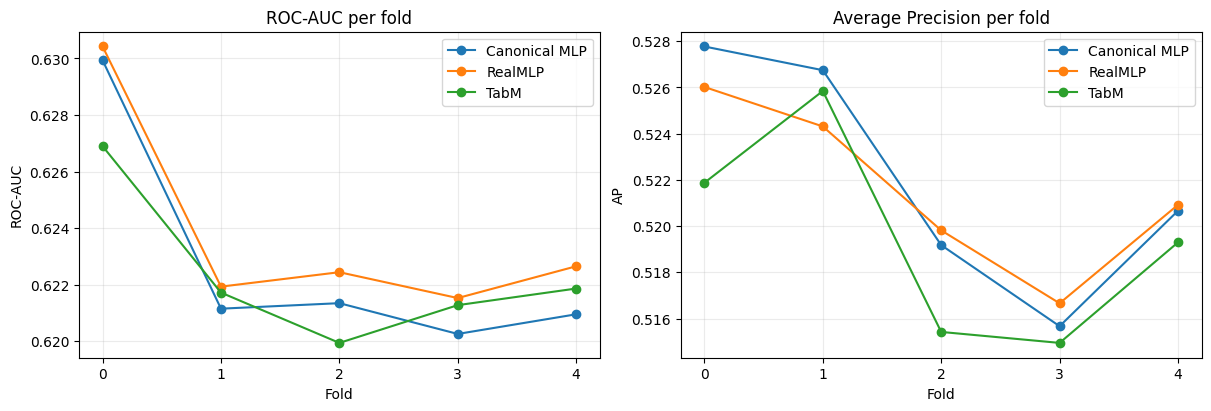

In [3]:
folds = fold_metric_frame(models)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for name, group in folds.groupby('model', sort=False):
    axes[0].plot(group['fold'], group['roc_auc'], marker='o', label=name)
    axes[1].plot(group['fold'], group['average_precision'], marker='o', label=name)
axes[0].set(title='ROC-AUC per fold', xlabel='Fold', ylabel='ROC-AUC', xticks=range(5))
axes[1].set(title='Average Precision per fold', xlabel='Fold', ylabel='AP', xticks=range(5))
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()

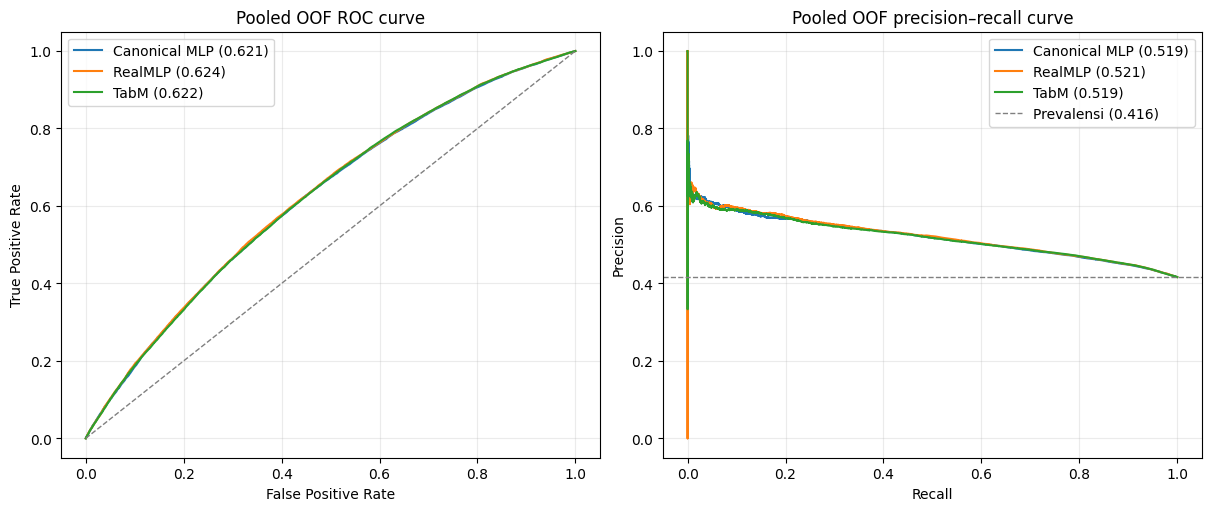

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
prevalence = next(iter(models.values()))['true_label'].mean()
for name, frame in models.items():
    fpr, tpr, _ = roc_curve(frame['true_label'], frame['probability'])
    precision, recall, _ = precision_recall_curve(frame['true_label'], frame['probability'])
    axes[0].plot(fpr, tpr, label=f"{name} ({summary.loc[name, 'roc_auc_pooled']:.3f})")
    axes[1].plot(recall, precision, label=f"{name} ({summary.loc[name, 'ap_pooled']:.3f})")
axes[0].plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
axes[1].axhline(prevalence, linestyle='--', color='grey', linewidth=1, label=f'Prevalensi ({prevalence:.3f})')
axes[0].set(title='Pooled OOF ROC curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[1].set(title='Pooled OOF precision–recall curve', xlabel='Recall', ylabel='Precision')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()

## Interpretasi yang diperbolehkan

C1 mengkarakterisasi predictive signal empat metadata dengan outer-fold ROC-AUC dan AP yang sama. Perbedaan internal fitting criterion tetap mengikuti kontrak model. Canonical MLP dipertahankan karena menyediakan latent representation neural 128-dimensi yang konsisten untuk intermediate fusion S3; C1 bukan tahap pemilihan encoder S3.

In [5]:
best_auc = summary['roc_auc_pooled'].idxmax()
best_ap = summary['ap_pooled'].idxmax()
print(f'ROC-AUC pooled tertinggi: {best_auc} ({summary.loc[best_auc, "roc_auc_pooled"]:.4f})')
print(f'AP pooled tertinggi: {best_ap} ({summary.loc[best_ap, "ap_pooled"]:.4f})')
print('Keputusan metodologis tetap: Canonical MLP digunakan sebagai S1 dan encoder metadata S3.')

ROC-AUC pooled tertinggi: RealMLP (0.6238)
AP pooled tertinggi: RealMLP (0.5210)
Keputusan metodologis tetap: Canonical MLP digunakan sebagai S1 dan encoder metadata S3.
